<a href="https://colab.research.google.com/github/mukayesh2004-ui/linear-regression/blob/main/Copy_of_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/spotify_churn_dataset.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 750.1+ KB


In [ ]:
df.describe()

,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,37.662125,154.068250,50.127250,0.300127,6.943875,0.747750,0.258875
std,2309.54541,12.740359,84.015596,28.449762,0.173594,13.617953,0.434331,0.438044
min,1.00000,16.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2000.75000,26.000000,81.000000,25.000000,0.150000,0.000000,0.000000,0.000000
50%,4000.50000,38.000000,154.000000,50.000000,0.300000,0.000000,1.000000,0.000000
75%,6000.25000,49.000000,227.000000,75.000000,0.450000,5.000000,1.000000,1.000000
max,8000.00000,59.000000,299.000000,99.000000,0.600000,49.000000,1.000000,1.000000


In [ ]:
df.assign()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,Other,44,DE,Student,237,36,0.30,Mobile,0,1,1
7996,7997,Male,34,AU,Premium,61,64,0.59,Mobile,0,1,0
7997,7998,Female,17,US,Free,81,62,0.33,Desktop,5,0,0
7998,7999,Female,34,IN,Student,245,94,0.27,Desktop,0,1,0


In [ ]:
df.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [ ]:
df.tail()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
7995,7996,Other,44,DE,Student,237,36,0.30,Mobile,0,1,1
7996,7997,Male,34,AU,Premium,61,64,0.59,Mobile,0,1,0
7997,7998,Female,17,US,Free,81,62,0.33,Desktop,5,0,0
7998,7999,Female,34,IN,Student,245,94,0.27,Desktop,0,1,0
7999,8000,Other,45,AU,Free,210,68,0.46,Desktop,6,0,0


In [ ]:
df.dropna(subset='user_id')

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,Other,44,DE,Student,237,36,0.30,Mobile,0,1,1
7996,7997,Male,34,AU,Premium,61,64,0.59,Mobile,0,1,0
7997,7998,Female,17,US,Free,81,62,0.33,Desktop,5,0,0
7998,7999,Female,34,IN,Student,245,94,0.27,Desktop,0,1,0


In [ ]:
df.query('age < 40 and country == "DE"')

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
10,11,Other,33,DE,Free,86,44,0.11,Web,37,0,0
16,17,Female,36,DE,Student,181,93,0.23,Mobile,0,1,0
18,19,Female,34,DE,Family,160,32,0.35,Mobile,0,1,0
43,44,Male,37,DE,Family,90,89,0.40,Mobile,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
7877,7878,Male,36,DE,Premium,193,45,0.52,Web,0,1,1
7897,7898,Other,38,DE,Premium,248,57,0.06,Web,0,1,0
7899,7900,Other,31,DE,Family,53,97,0.07,Web,0,1,0
7909,7910,Other,35,DE,Student,100,8,0.59,Desktop,0,1,0


In [ ]:
df.shape

(5330, 12)

In [ ]:
1

1

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
6,7,Female,39,UK,Premium,289,44,0.38,Desktop,0,1,0
7,8,Female,41,UK,Free,210,68,0.11,Mobile,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
7994,7995,Male,34,PK,Family,21,77,0.56,Desktop,0,1,0
7995,7996,Other,44,DE,Student,237,36,0.30,Mobile,0,1,1
7996,7997,Male,34,AU,Premium,61,64,0.59,Mobile,0,1,0
7998,7999,Female,34,IN,Student,245,94,0.27,Desktop,0,1,0


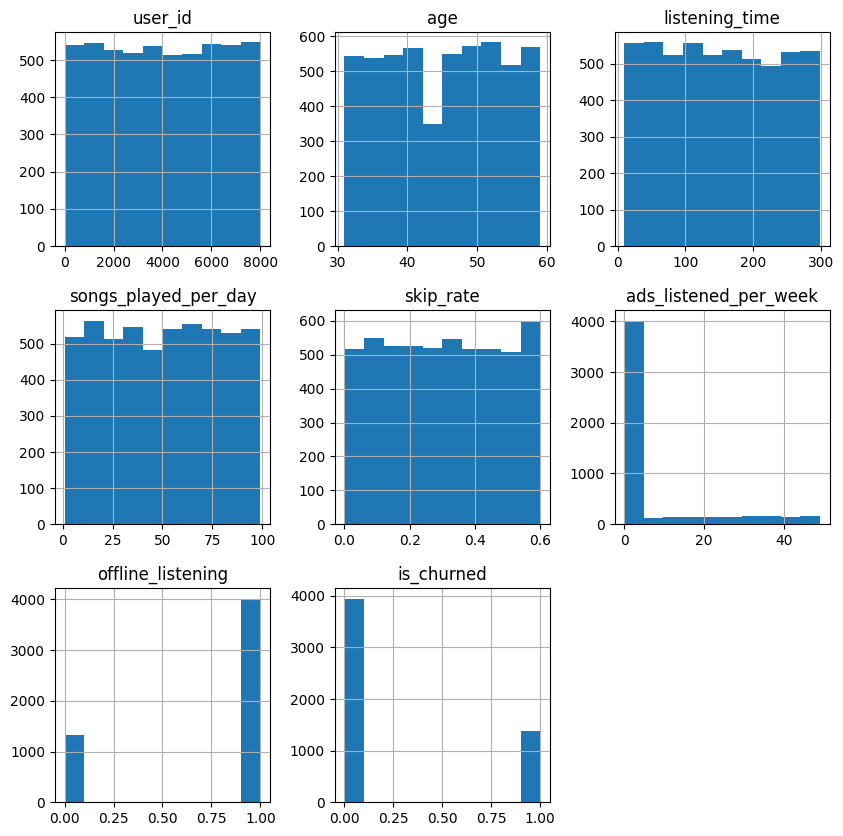

In [ ]:
df.hist(figsize=(10,10))
df

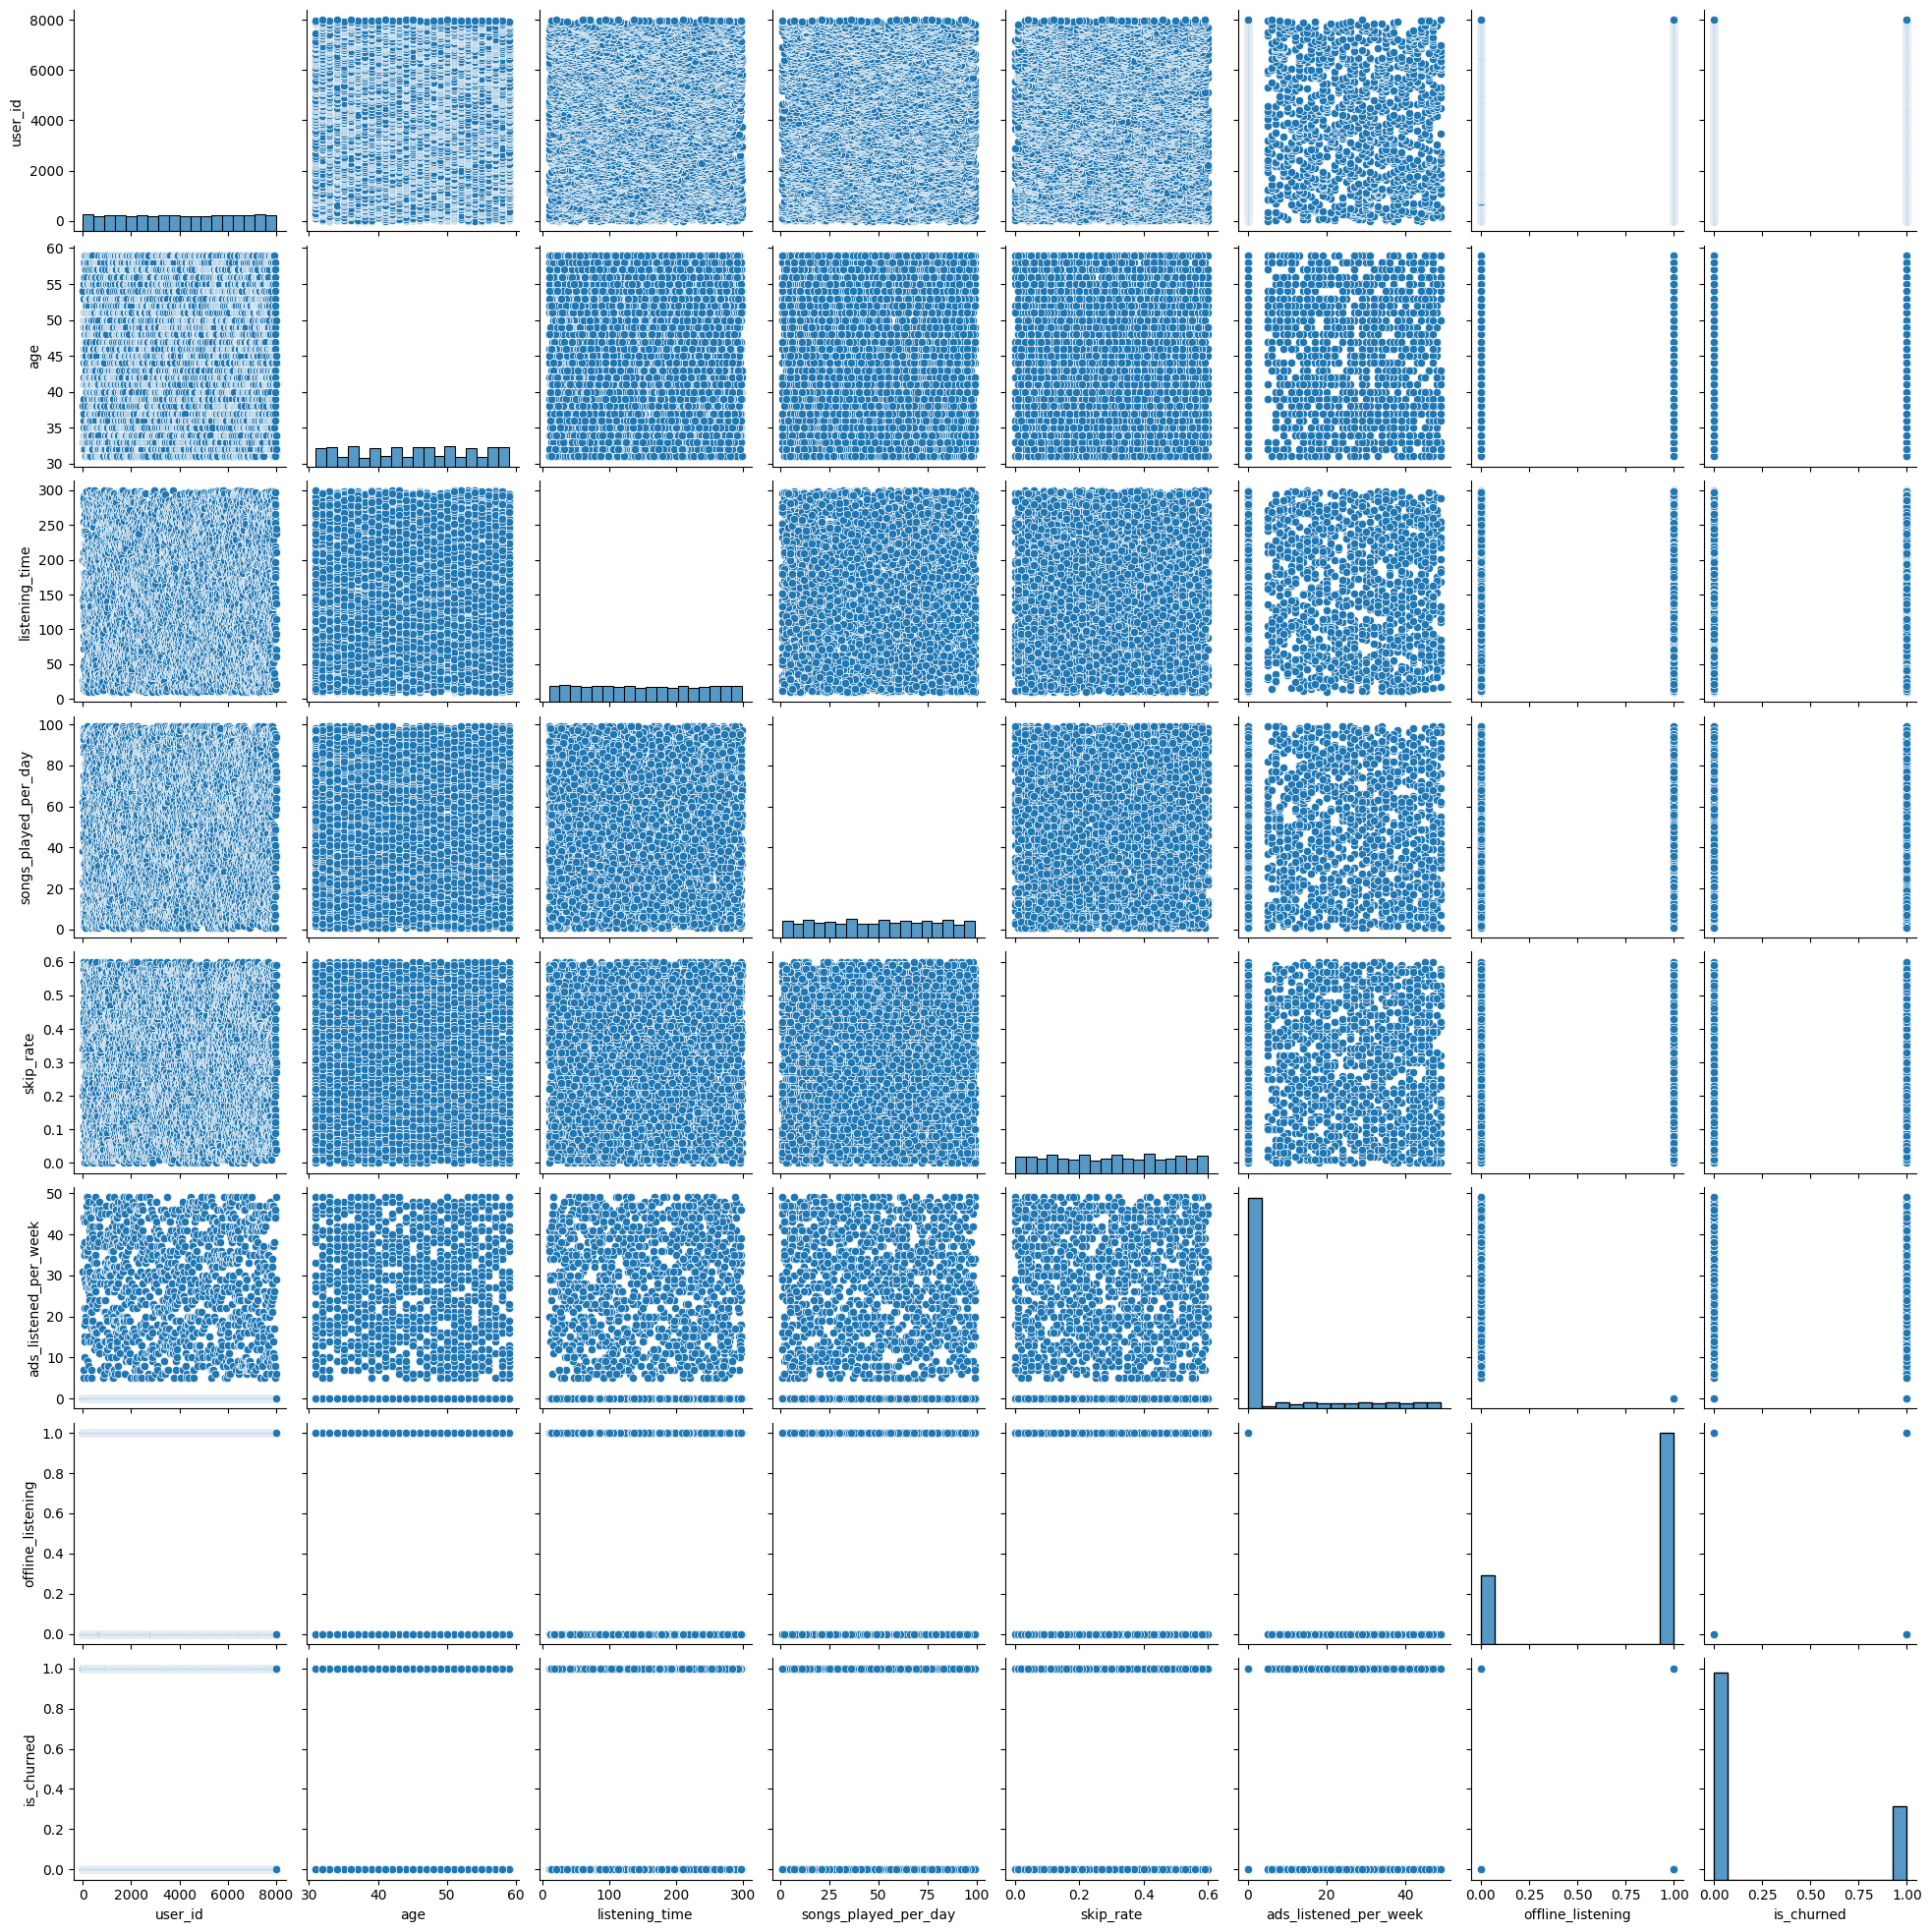

In [ ]:
sns.pairplot(df)

In [ ]:
x=df.drop('gender',axis=1)
y=df['gender']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(
x,y,test_size=0.2,random_state=42
)

In [ ]:
x_train

,user_id,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
4224,4225,36,FR,Free,72,65,0.43,Mobile,24,0,0
5829,5830,40,IN,Free,103,85,0.38,Mobile,33,0,1
754,755,33,CA,Free,100,8,0.02,Mobile,45,0,0
88,89,50,PK,Family,99,15,0.15,Mobile,0,1,0
4587,4588,50,FR,Premium,129,25,0.34,Mobile,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
4669,4670,32,AU,Student,243,79,0.36,Desktop,0,1,1
5699,5700,49,AU,Free,12,41,0.41,Mobile,38,0,0
7793,7794,55,IN,Premium,141,55,0.46,Mobile,0,1,1
7844,7845,59,UK,Premium,275,1,0.29,Web,0,1,0


In [ ]:
x_test

,user_id,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
1970,1971,52,PK,Student,175,28,0.16,Web,0,1,1
2749,2750,40,AU,Free,29,87,0.29,Mobile,25,0,0
1186,1187,37,PK,Free,194,56,0.16,Web,13,0,0
5827,5828,35,FR,Family,249,64,0.56,Web,0,1,0
6859,6860,41,FR,Free,40,44,0.39,Web,43,0,0
...,...,...,...,...,...,...,...,...,...,...,...
4283,4284,51,FR,Family,291,72,0.33,Desktop,0,1,0
7819,7820,47,FR,Family,44,83,0.05,Desktop,0,1,1
2947,2948,52,FR,Student,111,33,0.16,Mobile,0,1,0
6839,6840,57,IN,Family,223,19,0.46,Mobile,0,1,0


In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train_encoded,y_train_encoded)

LinearRegression()

In [ ]:
from sklearn.metrics import accuracy_score
y_pred=model.predict(x_test_encoded)

In [ ]:
y_pred=model.predict(x_test_encoded)
y_pred

NameError: name 'model' is not defined

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse=mean_squared_error(y_test_encoded,y_pred)
mae=mean_absolute_error(y_test_encoded,y_pred)
r_square=r2_score(y_test_encoded,y_pred)
print(f'MSE:{mse}')
print(f'MAE:{mae}')
print(f'R2_Score:{r_square}')

MSE:0.6586304915104472
MAE:0.6709646430862474
R2_Score:0.001278747031485894
